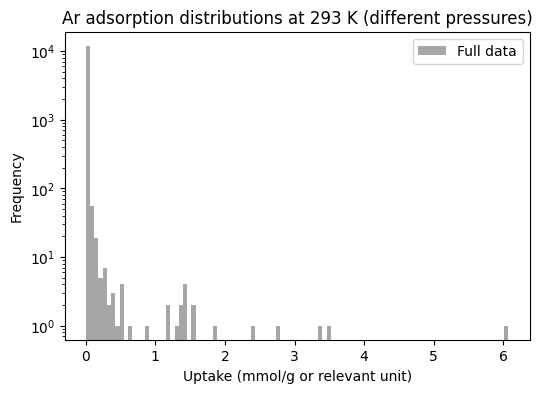

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv("../Grouped_Results/Ar_results_V4(rerun_applied).csv")

# Ar 293K 관련 컬럼만 선택
cols_293 = [c for c in df.columns if c.startswith("Ar_293_")]
data_293 = df[cols_293]

# 히스토그램 그리기
plt.figure(figsize=(6, 4))
for col in cols_293[:1]:
    plt.hist(data_293[col].dropna(), bins=100,
             alpha=0.7, color="gray", label="Full data")

plt.xlabel("Uptake (mmol/g or relevant unit)")
plt.ylabel("Frequency")
plt.title("Ar adsorption distributions at 293 K (different pressures)")
plt.legend()
plt.yscale("log")   # 분포 tail이 긴 경우 log scale 추천
plt.show()


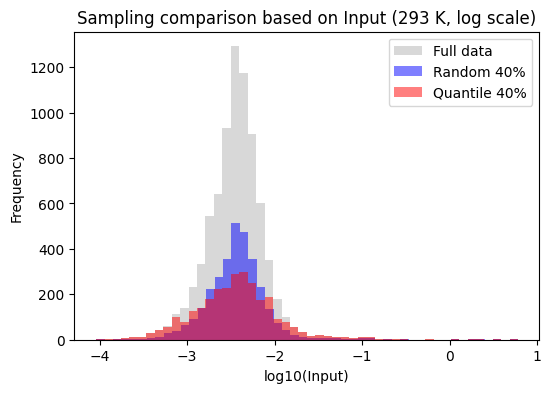

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 데이터 불러오기
df = pd.read_csv("../DataSet_PLDSCREENED/Ar_293K/Ar_293K_Ar_293_0.01_to_Ar_293_15_dataset.csv")

# Input 열 선택
vals = df["Input"].dropna().values

# 0인 값 제거 후 log 변환
vals = vals[vals > 0]
log_vals = np.log10(vals)

# ---- 1) Random 40% 샘플링 ----
rng = np.random.default_rng(42)
n_samples = int(len(log_vals) * 0.4)
random_sample = rng.choice(log_vals, size=n_samples, replace=False)

# ---- 2) Quantile 40% 샘플링 ----
def quantile_sample(values, n_bins=20, gamma=0.5, n_samples=1000, seed=0):
    rng = np.random.default_rng(seed)
    vmin, vmax = values.min(), values.max()
    edges = np.linspace(vmin, vmax, n_bins + 1)
    bin_ids = np.digitize(values, edges) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)
    
    idx = np.arange(len(values))
    bin_to_idx = {b: idx[bin_ids == b] for b in range(n_bins)}
    counts = np.array([len(bin_to_idx[b]) for b in range(n_bins)], dtype=float)
    
    valid = np.where(counts > 0)[0]
    weights = np.zeros_like(counts)
    weights[valid] = counts[valid] ** gamma
    probs = weights / weights.sum()
    
    raw = probs * n_samples
    quota = np.floor(raw).astype(int)
    deficit = n_samples - quota.sum()
    if deficit > 0:
        frac = raw - quota
        if frac.sum() > 0:
            add_bins = rng.choice(np.arange(n_bins), size=deficit, p=frac/frac.sum())
            for b in add_bins:
                quota[b] += 1
    
    selected = []
    for b in range(n_bins):
        if quota[b] > 0 and len(bin_to_idx[b]) > 0:
            chosen = rng.choice(bin_to_idx[b], size=min(quota[b], len(bin_to_idx[b])), replace=False)
            selected.append(chosen)
    return values[np.concatenate(selected)]

quantile_sampled = quantile_sample(log_vals, n_bins=20, gamma=0.5,
                                   n_samples=n_samples, seed=123)

# ---- Plot ----
plt.figure(figsize=(6,4))

# Full data
plt.hist(log_vals, bins=50, alpha=0.3, color="gray", label="Full data")

# Random 40%
plt.hist(random_sample, bins=50, alpha=0.5, color="blue", label="Random 40%")

# Quantile 40%
plt.hist(quantile_sampled, bins=50, alpha=0.5, color="red", label="Quantile 40%")

plt.xlabel("log10(Input)")
plt.ylabel("Frequency")
plt.title("Sampling comparison based on Input (293 K, log scale)")
plt.legend()
plt.show()
